데이터 처리 과정
(1) 전체 파일 로드 : 행, 열 개수/상위 5개 행/컬럼별 데이터 타입, 결측치 확인\
(2) Defects관련 컬럼을 불량 유형별로 정리하고, target 설정 -> Defects 관련 컬럼은 모두 삭제\
(3) 식별자 생성(id+Shot 병합)\
(4) 데이터를 시간순으로 정렬; 연속 공정이라 시간순으로 배열해서 가장 나중에 만들어진 데이터를 test로 사용해야 누수가 덜 생길 거 같아서\
(5) train / test 분리 피쳐와 target의 컬럼 목록을 새로운 변수로 정의한 뒤, train/test로 분리하면서 X, y를 정의하면 될 거 같기도..?\
(6) 단일값으로 존재하는 최대/최소 관련 컬럼들 삭제 <- test 데이터에서는 해당 컬럼을 그대로 갖고 있을 것이기 때문에 이 정보를 모델 학습에 사용하면 정보가 유출될 거 같아서\
(7) 공장 온도/습도 관련해 선형보간법으로 결측치를 대체하는 것은 train, test를 따로 각각 진행 <- 선형보간법의 원리 자체가 앞뒤 값을 통해 비어있는 사이의 값을 예측하는 것이라서\
(8) 이상치도 train, test 데이터에서 각각 처리\
: 단, IQR이나 z-score는 train 데이터로 계산하고, 동일한 값을 test에도 적용해야 한다고 함 --> 과거 데이터를 기준으로 새로운 데이터가 이상한지 판단해야 하니까!

In [34]:
# 라이브러리 호출
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

In [74]:
# 데이터 프레임을 출력할 때, 행과 컬럼이 모두 생략되지 않도록 하는 코드
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_csv("DieCasting_Quality_Raw_Data.csv", header=[0,1])
print("df shape:", df.shape)
df.head(20)

df shape: (7535, 57)


Process                                                                   \
        id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0        1            1    1      0.144      0.170      0.188         2.134   
1     1002            1    2      0.144      0.170      0.182         2.124   
2     2003            1    3      0.144      0.170      0.182         2.116   
3     3004            1    4      0.144      0.170      0.182         2.137   
4     4005            1    5      0.144      0.172      0.176         2.111   
5     5006            1    6      0.144      0.172      0.176         2.111   
6     6008            1    8      0.141      0.168      0.178         2.159   
7     7009            1    9      0.142      0.172      0.176         2.114   
8     8010            1   10      0.142      0.172      0.176         2.114   
9     9011            1   11      0.144      0.168      0.184         2.145   
10   10012            1   12      0.144      0.168      0.184         2.145   
11   11013            1   13      0.144      0.166      0.176         2.120   
12   12014            1   14      0.144      0.170      0.176         2.112   
13   13015            1   15      0.140      0.168      0.184         2.154   
14   14016            1   16      0.142      0.168      0.178         2.130   
15   15017            1   17      0.142      0.168      0.176         2.128   
16   16018            1   18      0.142      0.168      0.176         2.142   
17   17019            1   19      0.142      0.168      0.182         2.114   
18   18020            1   20      0.142      0.166      0.182         2.131   
19   19021            1   21      0.142      0.170      0.185         2.147   

                                                                         \
   Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0                214           0.008                 10             258   
1                217           0.008                 11             257   
2                214           0.008                 11             257   
3                217           0.008                 11             257   
4                217           0.008                 12             257   
5                217           0.008                 12             257   
6                214           0.008                 11             257   
7                217           0.008                 12             257   
8                217           0.008                 12             257   
9                217           0.008                 11             257   
10               217           0.008                 11             257   
11               217           0.008                 11             257   
12               214           0.010                 12             257   
13               217           0.008                 11             257   
14               214           0.007                 11             257   
15               217           0.008                 11             257   
16               214           0.008                 11             255   
17               217           0.009                 11             257   
18               214           0.008                 11             257   
19               217           0.008                 11             255   

                                                                            \
   Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0        20.7               0.044             1037        7.8          0.7   
1        20.7               0.044             1052        7.8          0.7   
2        20.8               0.041             1037        7.8          0.7   
3        20.7               0.043             1051        7.8          0.7   
4        20.7               0.042             1052        7.8          0.7   
5        20.7               0.042             1052        7.8      

In [36]:
# =========================
# 2) 메인 데이터 컬럼 구조 확인 (Process / Sensor / Defects)
# =========================
# MultiIndex 컬럼의 0레벨(최상위)의 컬럼들만 잘라서 가져옴
process_df = df.xs("Process", axis=1, level=0)
sensor_df  = df.xs("Sensor",  axis=1, level=0)
defects_df = df.xs("Defects", axis=1, level=0)

process_df.columns = process_df.columns.astype(str).str.strip()
sensor_df.columns  = sensor_df.columns.astype(str).str.strip()
defects_df.columns = defects_df.columns.astype(str).str.strip()

# Defects 값을 0/1로 통일

Defects관련 컬럼을 불량 유형별로 정리하고, target 설정 -> Defects 관련 컬럼은 모두 삭제\
타겟(Defects) 하나가 어떤 데이터에 매칭되어 있는건지 관계를 확실히 확인

In [37]:
# 0보다 크면 불량(1)로 바꾸기
defects_df = defects_df.apply(pd.to_numeric, errors="coerce").fillna(0)
defects_df = (defects_df > 0).astype(int)
# defects_df = (defects_df > 0).astype(int) # 불량유형 지정 안됨

In [38]:
col_uniques = defects_df.apply(lambda s: sorted(s.dropna().unique()))
col_uniques

Short_Shot_1       [0, 1]
Bubble_1           [0, 1]
Exfoliation_1      [0, 1]
Blow_Hole_1        [0, 1]
Stain_1            [0, 1]
Dent_1             [0, 1]
Deformation_1      [0, 1]
Contamination_1    [0, 1]
Impurity_1         [0, 1]
Crack_1            [0, 1]
Scratch_1          [0, 1]
Buring_Mark_1      [0, 1]
Inclusions_1          [0]
Short_Shot_2       [0, 1]
Bubble_2           [0, 1]
Exfoliation_2      [0, 1]
Blow_Hole_2        [0, 1]
Stain_2               [0]
Dent_2             [0, 1]
Deformation_2      [0, 1]
Contamination_2    [0, 1]
Impurity_2         [0, 1]
Crack_2            [0, 1]
Scratch_2             [0]
Buring_Mark_2         [0]
Inclusions_2       [0, 1]
dtype: object

# Cavity 1/2 통합 (Defects 통합)
이 shot에서 이 불량이 났냐? 기준으로 보면 맞음\
다만 Cavity 자체에 포커스를 맞추면 좋은 판단이 아님, 결국 cavity별 차이(1번만 불량/2번만 불량) 정보를 일부 버리는 것이기 때문

---
### Cavity 1/2 통합 비율 (Defects 통합 비율)

#### defects_df 0/1 비율 비교

In [7]:
# 원본 보관
defects_df_clean2 = defects_df.copy()

# cavity 1/2 컬럼 분리
c1 = defects_df_clean2[[c for c in defects_df_clean2.columns if c.endswith("_1")]].copy()
c2 = defects_df_clean2[[c for c in defects_df_clean2.columns if c.endswith("_2")]].copy()

# 컬럼명 통일
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

all_defects = sorted(set(c1.columns) | set(c2.columns))
c1 = c1.reindex(columns=all_defects, fill_value=0)
c2 = c2.reindex(columns=all_defects, fill_value=0)

In [8]:
# (추천) cavity 내 값이 2/3이 남아있을 수 있으니 "발생 여부"로 이진화
c1_bin = (c1 > 0).astype(int)
c2_bin = (c2 > 0).astype(int)

# ✅ 합으로 통합: 0/1/2 (각 defect가 몇 개 cavity에서 발생했는지)
defects_merged = c1_bin + c2_bin
defects_df_clean2 = defects_merged

print("통합 전 defects_df shape:", defects_df.shape)
print("통합 후 defects_df_clean2 shape:", defects_df_clean2.shape)
print("값 종류:", np.unique(defects_df_clean2.to_numpy()))
defects_df_clean2.head(20)

통합 전 defects_df shape: (7535, 26)
통합 후 defects_df_clean2 shape: (7535, 13)
값 종류: [0 1 2]


,Blow_Hole,Bubble,Buring_Mark,Contamination,Crack,Deformation,Dent,Exfoliation,Impurity,Inclusions,Scratch,Short_Shot,Stain
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,1,0,0,0,0,0,0,0


In [9]:
# 전체 셀 기준(모든 defect 칸을 다 펼쳐서 0/1/2 비율)
flat = defects_df_clean2.to_numpy().ravel()
dist_all = pd.Series(flat).value_counts(normalize=True).reindex([0,1,2], fill_value=0)
print("=== 전체 셀 기준 0/1/2 비율 ===")
print((dist_all * 100).round(2).astype(str) + "%")

=== 전체 셀 기준 0/1/2 비율 ===
0    98.16%
1     1.81%
2     0.03%
Name: proportion, dtype: object


#### defects_df 그룹화 한 이후 0/1/2+ 비율

In [10]:
# 1) 그룹 정의
groups = {
    "Surface_Defect": ["Stain", "Dent", "Scratch", "Burning_Mark"],                                     # 표면 불량
    "Structural_Defect": ["Short_Shot", "Bubble", "Blow_Hole", "Deformation", "Crack", "Exfoliation"],  # 구조 불량
    "Contamination_Defect": ["Contamination", "Impurity", "Inclusions"],                                # 이물질 포함 불량
}

# 2) 그룹 컬럼 만들기 + 값 합치기 (defects_df_clean2 기준)
group_df_sum = pd.DataFrame(index=defects_df_clean2.index)

for g, members in groups.items():
    group_df_sum[g] = defects_df_clean2.reindex(columns=members, fill_value=0).sum(axis=1).astype(int)

# 3) 0~4 개수/비율 테이블
n = len(group_df_sum)

dist_by_group = pd.DataFrame({
    "0_count": (group_df_sum == 0).sum(),
    "1_count": (group_df_sum == 1).sum(),
    "2_count": (group_df_sum == 2).sum(),
    "3_count": (group_df_sum == 3).sum(),
    "4_count": (group_df_sum == 4).sum(),
    "5plus_count": (group_df_sum >= 5).sum(),
})

dist_by_group["0_rate(%)"] = (dist_by_group["0_count"] / n * 100).round(2)
dist_by_group["1_rate(%)"] = (dist_by_group["1_count"] / n * 100).round(2)
dist_by_group["2_rate(%)"] = (dist_by_group["2_count"] / n * 100).round(2)
dist_by_group["3_rate(%)"] = (dist_by_group["3_count"] / n * 100).round(2)
dist_by_group["4_rate(%)"] = (dist_by_group["4_count"] / n * 100).round(2)
dist_by_group["5plus_rate(%)"] = (dist_by_group["5plus_count"] / n * 100).round(2)

# 4) 네 기준대로 정렬
dist_by_group = dist_by_group.sort_values("5plus_rate(%)", ascending=False)

display(dist_by_group)

,0_count,1_count,2_count,3_count,4_count,5plus_count,0_rate(%),1_rate(%),2_rate(%),3_rate(%),4_rate(%),5plus_rate(%)
Surface_Defect,7333,202,0,0,0,0,97.32,2.68,0.00,0.00,0.0,0.0
Structural_Defect,6022,1416,96,1,0,0,79.92,18.79,1.27,0.01,0.0,0.0
Contamination_Defect,7516,18,1,0,0,0,99.75,0.24,0.01,0.00,0.0,0.0


In [11]:
group_df_sum.head(20)

,Surface_Defect,Structural_Defect,Contamination_Defect
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,1,0


---
## Cavity 1/2 통합

In [39]:
# 원본 보관?
defects_df_clean = defects_df.copy()

# cavity 1/2 컬럼 분리
c1 = defects_df_clean[[c for c in defects_df_clean.columns if c.endswith("_1")]].copy()
c2 = defects_df_clean[[c for c in defects_df_clean.columns if c.endswith("_2")]].copy()

# 컬럼명 통일: Short_Shot_1 -> Short_Shot
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 제대로 분리되었는지 확인
print("c1 shape:", c1.shape)
print("c2 shape:", c2.shape)
print("c1, c2 컬럼이 동일한가?", set(c1.columns) == set(c2.columns))

c1 shape: (7535, 13)
c2 shape: (7535, 13)
c1, c2 컬럼이 동일한가? True


In [40]:
# OR 방식으로 통합: 둘 중 하나라도 1이면 1
defects_merged = ((c1 + c2) > 0).astype(int)   # (c1 | c2) 도 가능
defects_df_clean = defects_merged

print("통합 전 defects_df shape:", defects_df.shape)
print("통합 후 defects_df_clean shape:", defects_df_clean.shape)
print("값 종류:", np.unique(defects_df_clean.to_numpy()))
defects_df_clean.head(20)

통합 전 defects_df shape: (7535, 26)
통합 후 defects_df_clean shape: (7535, 13)
값 종류: [0 1]


,Short_Shot,Bubble,Exfoliation,Blow_Hole,Stain,Dent,Deformation,Contamination,Impurity,Crack,Scratch,Buring_Mark,Inclusions
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,1,0,0,0,0,0,0


In [41]:
# 전체 셀 기준(모든 defect 칸을 다 펼쳐서 0/1/2 비율)
flat = defects_df_clean.to_numpy().ravel()
dist_all = pd.Series(flat).value_counts(normalize=True).reindex([0,1,2], fill_value=0)
print("=== 전체 셀 기준 0/1/2 비율 ===")
print((dist_all * 100).round(2).astype(str) + "%")

=== 전체 셀 기준 0/1/2 비율 ===
0    98.16%
1     1.84%
2      0.0%
Name: proportion, dtype: object


# 각 불량 유형별로 묶음 (표면, 구조, 이물질 등)
분류 기준 정하고 하기, 모델링 한다고 했을때 결국 타겟값(defects)은 줄이는게 정답임

1. Short_Shot: 미성형(충전 부족) 불량 — 용탕이 금형 끝까지 다 채워지지 않아 모서리/얇은 부위가 덜 찍히거나 일부가 비는 현상.
2. Bubble: 기포 불량 — 주조 중 갇힌 가스/공기가 내부나 표면에 기포로 남아 강도 저하·누설/외관 불량을 유발.
3. Exfoliation: 박리(층 분리/벗겨짐) 불량 — 표면층이 뜨거나 층이 분리되어 벗겨지는 형태로, 표면 품질·내구성을 크게 떨어뜨림.
4. Blow_Hole: 블로홀/기공 불량 — 응고 중 가스/수축으로 생긴 비교적 큰 공극(구멍)으로, 단면 기공·핀홀처럼 나타남.
5. Stain: 얼룩 불량 — 산화막/윤활제/오염 영향으로 표면 색이 불균일하게 남아 얼룩처럼 보이는 외관 불량.
6. Dent: 찍힘/눌림 불량 — 취출·이송·적재 과정에서 충격/압력으로 표면이 눌리거나 자국이 생긴 외관/치수 불량.
7. Scratch: 스크래치 불량 — 금형, 이송 설비, 공구, 적재 간 마찰로 표면에 선형 흠집이 생기는 외관 불량.
8. Buring_Mark: 번마크/그을림 불량 — 고온 가스/산화 영향으로 표면이 그을리거나 변색되는 현상(검게 타거나 갈변).
9. Deformation: 변형 불량 — 응고 후 취출·냉각·후공정 중 응력/열로 휘어짐·뒤틀림이 생겨 형상/치수가 틀어짐.
10. Crack: 균열 불량 — 응고수축·열응력·과도한 취출력 등으로 미세~육안 균열이 발생해 파손 위험이 커짐.
11. Contamination: 오염(이물) 불량 — 분진/오일/칩 등 외부 이물이 표면에 붙거나 끼어 도장·외관·조립성 문제를 만듦.
12. Impurity: 불순물 불량 — 용탕 내 불순 성분/산화물 등이 섞여 품질이 저하되고 표면 결함·취성 증가로 이어짐.
13. Inclusions: 개재물(내부 이물) 불량 — 산화막/슬래그 등 비금속물이 내부에 갇혀 단면에 점/덩어리로 보이며 강도를 약화.

- 표면 불량 : 육안으로 확인 가능하지만, 금속의 분리나 갈라짐은 없는 불량 (Stain, Dent, Scratch, Burning_Mark)
- 구조 불량: 육안으로 금속의 분리·갈라짐이 보이거나, 제품의 강도·기능에 직접 영향을 줄 수 있는 불량 (Short_Shot, Bubble, Blow_Hole, Deformation, Crack, Exfoliation)
- 이물질 포함 불량: 원래 포함되면 안 되는 외부 물질이 들어간 불량 (Contamination, Impurity, Inclusions)

In [42]:
# 1) 그룹 정의
# 그룹별 OR(하나라도 1이면 1)로 합치기
group_df = pd.DataFrame(index=defects_df_clean.index)

group_df["Surface_Defect"] = ( # 표면 불량
    defects_df_clean.reindex(columns=["Stain", "Dent", "Scratch", "Burning_Mark"], fill_value=0).max(axis=1)
)

group_df["Structural_Defect"] = ( # 구조 불량
    defects_df_clean.reindex(columns=["Short_Shot", "Bubble", "Blow_Hole", "Deformation", "Crack", "Exfoliation"], fill_value=0).max(axis=1)
)

group_df["Contamination_Defect"] = ( # 이물질 포함 불량
    defects_df_clean
    .reindex(columns=["Contamination", "Impurity", "Inclusions"], fill_value=0)
    .max(axis=1)
)

print("group_df shape:", group_df.shape)
print("값 종류:", np.unique(group_df.to_numpy()))
display((group_df.mean() * 100).round(2).sort_values(ascending=False))
group_df.info()

group_df shape: (7535, 3)
값 종류: [0 1]


Structural_Defect       20.08
Surface_Defect           2.68
Contamination_Defect     0.25
dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Surface_Defect        7535 non-null   int64
 1   Structural_Defect     7535 non-null   int64
 2   Contamination_Defect  7535 non-null   int64
dtypes: int64(3)
memory usage: 176.7 KB


# 결측값 처리(Sensor 중심) **!!split 후에 train/test 각각 따로 보간해야 됨!!**
생각해봤는데 이 데이터엔 timestamp가 없고 행 순서가 시간 순서라는 보장도 없는데 선행보간법을 하는게 맞나?\
회의를 한 뒤에 더 안전/간단한 방법인 중앙값으로 파이프라인으로 넣기

_Min/_Max...\
상수값이니까 상관없나

In [43]:
# =========================
# 결측치(NA) 구조 확인 (+ 컬럼별 비율)
# =========================
print("===== 결측치(NA) 확인 =====")

n_rows = len(df)

na_count = df.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0]

# 그룹별 결측치 개수(총 결측 수) - 기존 그대로
print("그룹별 결측치 합(총 결측 수):")
print(pd.Series({
    "Process": process_df.isna().sum().sum(),
    "Sensor":  sensor_df.isna().sum().sum(),
    "Defects": defects_df.isna().sum().sum()
}))
print()

# 컬럼별 결측치 개수
print("결측치가 있는 컬럼만(개수):")
print(na_cols)
print()

# 컬럼별 결측치 비율(%): (결측 행 수 / 전체 행 수) * 100
print("결측치가 있는 컬럼만(비율 %):")
print(((na_cols / n_rows) * 100).round(4))
print()

===== 결측치(NA) 확인 =====
그룹별 결측치 합(총 결측 수):
Process      0
Sensor     540
Defects      0
dtype: int64

결측치가 있는 컬럼만(개수):
Sensor  Factory_Temp            90
        Factory_Humidity        90
        Factory_Temp_Max        90
        Factory_Humidity_Max    90
        Factory_Humidity_Min    90
        Factory_Temp_Min        90
dtype: int64

결측치가 있는 컬럼만(비율 %):
Sensor  Factory_Temp            1.1944
        Factory_Humidity        1.1944
        Factory_Temp_Max        1.1944
        Factory_Humidity_Max    1.1944
        Factory_Humidity_Min    1.1944
        Factory_Temp_Min        1.1944
dtype: float64



sensor_df

# Sensor에서 _MIN/_MAX로 끝나는 컬럼 찾아서 삭제
minmax_cols = [c for c in sensor_df.columns if c.endswith("_Min") or c.endswith("_Max")]
sensor_df_clean = sensor_df.drop(columns=minmax_cols)

print("삭제한 _MIN/_MAX 컬럼 수:", len(minmax_cols))
print("삭제 전 sensor_df shape:", sensor_df.shape)
print("삭제 후 sensor_df shape:", sensor_df_clean.shape)

In [ ]:
minmax_cols = [c for c in sensor_df.columns if c.endswith("_Min") or c.endswith("_Max")]
sensor_df_clean = sensor_df.drop(columns=minmax_cols)

print("삭제한 _MIN/_MAX 컬럼 수:", len(minmax_cols))
print("삭제 전 sensor_df shape:", sensor_df.shape)
print("삭제 후 sensor_df shape:", sensor_df_clean.shape)

In [61]:
sensor_df_clean= sensor_df.copy()
sensor_df_clean.head()

,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max
0,695.0,6.3,3,9,26.0,10,50,2.71,32.9,18.0,22.0,58.4,18.0,22.0
1,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0
2,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0
3,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0
4,697.9,6.4,3,9,26.1,10,50,2.69,32.9,18.0,22.0,57.8,18.0,22.0


In [62]:
# =========================
# 결측치(NA) 구조 확인 (+ 컬럼별 비율)
# =========================
print("===== 결측치(NA) 확인 =====")

n_rows = len(sensor_df_clean)

na_count = sensor_df_clean.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0]

# 컬럼별 결측치 개수
print("결측치가 있는 컬럼만(개수):")
print(na_cols)
print()


===== 결측치(NA) 확인 =====
결측치가 있는 컬럼만(개수):
Factory_Humidity_Max    90
Factory_Humidity_Min    90
Factory_Temp_Max        90
Factory_Humidity        90
Factory_Temp            90
Factory_Temp_Min        90
dtype: int64



In [63]:
sensor_df_clean[["Factory_Temp", "Factory_Humidity"]] = (
    sensor_df_clean[["Factory_Temp", "Factory_Humidity"]]
    .interpolate(method="linear", limit_direction="both")
)
print(sensor_df_clean.isna().sum())

Melting_Furnace_Temp     0
Air_Pressure             0
Air_Pressure_Min         0
Air_Pressure_Max         0
Coolant_Temp             0
Coolant_Temp_Min         0
Coolant_Temp_Max         0
Coolant_Pressure         0
Factory_Temp             0
Factory_Temp_Min        90
Factory_Temp_Max        90
Factory_Humidity         0
Factory_Humidity_Min    90
Factory_Humidity_Max    90
dtype: int64


In [66]:
# Min, Max 값 처리
cols = ["Factory_Temp_Min", "Factory_Temp_Max", "Factory_Humidity_Min", "Factory_Humidity_Max"]

# 각 컬럼에서 결측이 아닌 값 중 첫 값으로 결측 채우기(상수 컬럼이면 이게 곧 고정값)
for c in cols:
    fill_val = sensor_df_clean[c].dropna().iloc[0]
    sensor_df_clean[c] = sensor_df_clean[c].fillna(fill_val)

print(sensor_df_clean.isna().sum())

Melting_Furnace_Temp    0
Air_Pressure            0
Air_Pressure_Min        0
Air_Pressure_Max        0
Coolant_Temp            0
Coolant_Temp_Min        0
Coolant_Temp_Max        0
Coolant_Pressure        0
Factory_Temp            0
Factory_Temp_Min        0
Factory_Temp_Max        0
Factory_Humidity        0
Factory_Humidity_Min    0
Factory_Humidity_Max    0
dtype: int64


# 이상치 처리 **!!split 후에 train/test 각각 따로 보간해야 됨!!**
기준: 왜도 < |2|, 첨도 < |8| 범위에 하나라도 못 맞추면 → IQR 사용

In [48]:
process_df_clean = process_df.copy()

In [49]:
proc_skew = process_df_clean.skew(skipna=True)
proc_kurt = process_df_clean.kurt(skipna=True)

sens_skew = sensor_df_clean.skew(skipna=True)
sens_kurt = sensor_df_clean.kurt(skipna=True)

# 보기 좋게 표로
proc_stat = pd.DataFrame({"skew": proc_skew, "kurt": proc_kurt})
sens_stat = pd.DataFrame({"skew": sens_skew, "kurt": sens_kurt})

In [50]:
# =========================
# 2) 기준 위반 컬럼만 추출
# =========================
skew_th, kurt_th = 2.0, 8.0

proc_bad_mask = (proc_stat["skew"].abs() >= skew_th) | (proc_stat["kurt"].abs() >= kurt_th)
sens_bad_mask = (sens_stat["skew"].abs() >= skew_th) | (sens_stat["kurt"].abs() >= kurt_th)

proc_bad_cols = proc_stat.index[proc_bad_mask].tolist()
sens_bad_cols = sens_stat.index[sens_bad_mask].tolist()

print("=== Process 위반 컬럼 수 ===", len(proc_bad_cols))
print(proc_bad_cols)

print("\n=== Sensor 위반 컬럼 수 ===", len(sens_bad_cols))
print(sens_bad_cols)

# (원하면) 위반 컬럼 통계만 보기
display(proc_stat.loc[proc_bad_cols].sort_values(["skew","kurt"], key=lambda s: s.abs(), ascending=False))
display(sens_stat.loc[sens_bad_cols].sort_values(["skew","kurt"], key=lambda s: s.abs(), ascending=False))

=== Process 위반 컬럼 수 === 2
['Velocity_2', 'Cycle_Time']

=== Sensor 위반 컬럼 수 === 0
[]


,skew,kurt
Cycle_Time,5.316293,92.781942
Velocity_2,4.087670,28.913573


,skew,kurt


'Velocity_2', 'Cycle_Time'은 IQR 기준으로 전처리\
나머지 값은 z-score 기준으로 전처리

In [68]:
print(process_df_clean.columns)

print(sensor_df_clean.columns)

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time'],
      dtype='object')
Index(['Melting_Furnace_Temp', 'Air_Pressure', 'Air_Pressure_Min',
       'Air_Pressure_Max', 'Coolant_Temp', 'Coolant_Temp_Min',
       'Coolant_Temp_Max', 'Coolant_Pressure', 'Factory_Temp',
       'Factory_Temp_Min', 'Factory_Temp_Max', 'Factory_Humidity',
       'Factory_Humidity_Min', 'Factory_Humidity_Max'],
      dtype='object')


---
### Min, Max 있는 값들 분포 확인

In [73]:
# High_Velocity보다 큰 값 찾기
hv = process_df_clean["High_Velocity"]

# Velocity_1, Velocity_2, Velocity_3 중 하나라도 High_Velocity 크면 규직 위반
mask_violate = (
    (process_df_clean["Velocity_1"] > hv) |
    (process_df_clean["Velocity_2"] > hv) |
    (process_df_clean["Velocity_3"] > hv)
)

print("규칙 위반 행 개수:", mask_violate.sum())
display(process_df_clean.loc[mask_violate,
                            [
                            "Velocity_1","Velocity_2","Velocity_3",
                            "High_Velocity"]])

규칙 위반 행 개수: 4


,Velocity_1,Velocity_2,Velocity_3,High_Velocity
3347,0.141,0.168,0.181,0.0
3348,0.141,0.168,0.181,0.0
3419,0.144,0.168,0.181,0.0
3420,0.144,0.168,0.181,0.0


In [75]:
process_df_clean["High_Velocity"].describe()

count    7535.000000
mean        2.319210
std         0.222041
min         0.000000
25%         2.134000
50%         2.161000
75%         2.523000
max         2.744000
Name: High_Velocity, dtype: float64

In [58]:
# Spray_Time보다 큰 값 찾기
hs = process_df_clean["Spray_Time"]

#  Spray_1_Time 또는 Spray_2_Time 이 Spray_Time 보다 크면 규칙 위반
mask_violate = (
    (process_df_clean["Spray_1_Time"] > hs) |
    (process_df_clean["Spray_2_Time"] > hs) 
)

print("규칙 위반 행 개수:", mask_violate.sum())
display(process_df_clean.loc[mask_violate,
                            [
                            "id","Product_Type","Shot", # 식별자
                            "Spray_1_Time","Spray_2_Time",
                            "Spray_Time"]])

규칙 위반 행 개수: 0


,id,Product_Type,Shot,Spray_1_Time,Spray_2_Time,Spray_Time


In [59]:
# Spray_Time보다 큰 값 찾기 (Spray_1_Time + Spray_2_Time)
hs = process_df_clean["Spray_Time"]

# Spray_1_Time + Spray_2_Time 이 Spray_Time 보다 크면 규칙 위반
mask_violate = (process_df_clean["Spray_1_Time"] + process_df_clean["Spray_2_Time"]) > hs

print("규칙 위반 행 개수:", mask_violate.sum())
display(process_df_clean.loc[mask_violate,
                            [
                            "id","Product_Type","Shot", # 식별자
                            "Spray_1_Time","Spray_2_Time",
                            "Spray_Time"]])

규칙 위반 행 개수: 0


,id,Product_Type,Shot,Spray_1_Time,Spray_2_Time,Spray_Time


In [70]:
# Coolant_Temp 범위 위반
x = sensor_df_clean["Coolant_Temp"]
mn = sensor_df_clean["Coolant_Temp_Min"]
mx = sensor_df_clean["Coolant_Temp_Max"]

mask_violate = (x < mn) | (x > mx)

print("Coolant_Temp 범위 위반 행 개수:", mask_violate.sum())
display(sensor_df_clean.loc[mask_violate,
                            [
                            "Coolant_Temp","Coolant_Temp_Min"
                            ,"Coolant_Temp_Max"]].head())

Coolant_Temp 범위 위반 행 개수: 0


,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max


In [71]:
# Factory_Temp 범위 위반
x = sensor_df_clean["Factory_Temp"]
mn = sensor_df_clean["Factory_Temp_Min"]
mx = sensor_df_clean["Factory_Temp_Max"]

mask_violate = (x < mn) | (x > mx)

print("Factory_Temp 범위 위반 행 개수:", mask_violate.sum())
display(sensor_df_clean.loc[mask_violate,
                            [
                            "Factory_Temp","Factory_Temp_Min"
                            ,"Factory_Temp_Max"]].head())

Factory_Temp 범위 위반 행 개수: 7535


,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max
0,32.9,18.0,22.0
1,32.9,18.0,22.0
2,32.9,18.0,22.0
3,32.9,18.0,22.0
4,32.9,18.0,22.0


In [72]:
# Factory_Humidity 범위 위반
x = sensor_df_clean["Factory_Humidity"]
mn = sensor_df_clean["Factory_Humidity_Min"]
mx = sensor_df_clean["Factory_Humidity_Max"]

mask_violate = (x < mn) | (x > mx)

print("Factory_Humidity 범위 위반 행 개수:", mask_violate.sum())
display(sensor_df_clean.loc[mask_violate,
                            [
                            "Factory_Humidity","Factory_Humidity_Min"
                            ,"Factory_Humidity_Max"]].head())

Factory_Humidity 범위 위반 행 개수: 7535


,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max
0,58.4,18.0,22.0
1,58.2,18.0,22.0
2,58.2,18.0,22.0
3,58.2,18.0,22.0
4,57.8,18.0,22.0


## 이상치 IQR

In [76]:
X = pd.concat([process_df_clean, sensor_df_clean], axis=1).drop(columns=["id"])
# 샷별 불량 개수(26개 defect 컬럼의 합)
defect_count = defects_df.sum(axis=1)
# (B) 이진 타겟(불량 하나라도 있으면 1)
y = (defect_count > 0).astype(int)

In [90]:
# 3) IQR 기반 이상치 마스크
q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr # lower 보다 작으면 이상치
upper = q3 + 1.5 * iqr # upper 보다 크면 이상치

# 이상치 마스크 만들기(True/False 표)
outlier_mask = X.lt(lower) | X.gt(upper) # True: 이상치, False: 정상
# X가 lower보다 작은지(less than) → True/False
# X가 upper보다 큰지(greater than) → True/False
# 둘 중 하나라도 True면 이상치(True)

# IQR=0인 컬럼은 이상치 판단이 의미 없을 수 있으니 제외
zero_iqr_cols = iqr.eq(0)
outlier_mask.loc[:, zero_iqr_cols] = False

# 4) 컬럼별 이상치 개수/비율
outlier_count_by_col = (
    outlier_mask
    .sum() # 이상치 총합
    .sort_values(ascending=False) # 이상치가 많은 컬럼부터 정렬
)
outlier_ratio_by_col = (outlier_count_by_col / len(X)).sort_values(ascending=False) # 비율화

print("===== 이상치 TOP 15: 개수 =====")
print(outlier_count_by_col.head(15))
print()

rows_with_any_outlier = outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any_outlier, "/", len(X))
print("비율:", rows_with_any_outlier / len(X))
print()

===== 이상치 TOP 15: 개수 =====
Factory_Temp          300
Velocity_2            184
Biscuit_Thickness      12
Cycle_Time             11
High_Velocity          10
Rapid_Rise_Time        10
Velocity_1              6
Pressure_Rise_Time      4
Velocity_3              4
Cylinder_Pressure       4
Product_Type            0
Clamping_Force          0
Casting_Pressure        0
Shot                    0
Spray_Time              0
dtype: int64

이상치가 1개라도 있는 행 수: 516 / 7535
비율: 0.06848042468480425



<Figure size 2800x800 with 0 Axes>

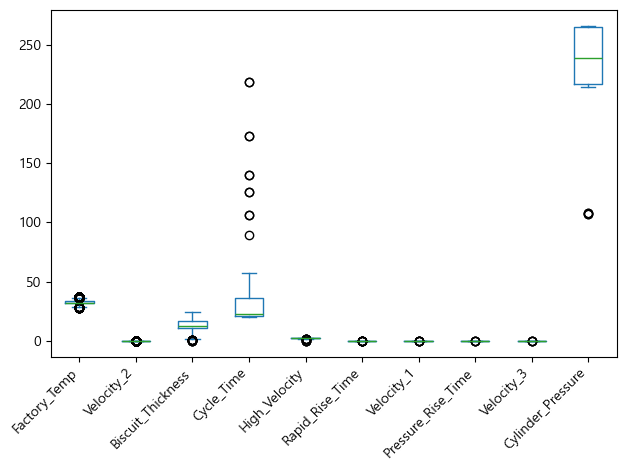

In [97]:
# 4) 시각화: 이상치 많은 컬럼 상위 6개 박스플롯
top_cols = outlier_count_by_col[outlier_count_by_col > 0].head(20).index

plt.figure(figsize=(28, 8))
X[top_cols].plot(kind="box")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [79]:
print("===== [Velocity_2, Cycle_Time] 컬럼 min/max =====")
print(X2[top_cols].agg(["min", "max"]))
print()

tmp = X2[top_cols].copy()
tmp["y"] = y

print("===== 불량/양품 평균(mean) 비교 =====")
print(tmp.groupby("y")[top_cols].mean())
print()

print("===== 불량/양품 중앙값(median) 비교 =====")
print(tmp.groupby("y")[top_cols].median())
print()

===== [Velocity_2, Cycle_Time] 컬럼 min/max =====
     Velocity_2  Cycle_Time
min       0.158        20.2
max       0.212       218.6

===== 불량/양품 평균(mean) 비교 =====
   Velocity_2  Cycle_Time
y                        
0    0.168863   27.247725
1    0.168583   29.425933

===== 불량/양품 중앙값(median) 비교 =====
   Velocity_2  Cycle_Time
y                        
0       0.168        22.5
1       0.168        35.0



## 이상치 z-score

In [84]:
# =========================
# Z-score(6σ) 이상치 "확인" (표 + 그래프 합본)
# =========================

z_th = 6

# 1) 컬럼별 평균/표준편차
mu = X.mean(numeric_only=True)
sigma = X.std(numeric_only=True, ddof=0)

# 표준편차 0인 컬럼 제외
sigma_zero = (sigma == 0)

# 2) Z-score & 이상치 마스크
z = (X - mu) / sigma
z_abs = z.abs()
z_outlier_mask = (z_abs > z_th)
z_outlier_mask.loc[:, sigma_zero] = False

# 3) 컬럼별 이상치 개수/비율
z_count = z_outlier_mask.sum().sort_values(ascending=False)
z_ratio = (z_count / len(X)).sort_values(ascending=False)

print("===== [Z-score 6σ] 이상치 TOP 15: 개수 =====")
print(z_count.head(15))
print()


rows_with_any = z_outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any, "/", len(X))
print("비율:", rows_with_any / len(X))
print()

===== [Z-score 6σ] 이상치 TOP 15: 개수 =====
Velocity_2            34
Cycle_Time            11
Pressure_Rise_Time     4
High_Velocity          4
Shot                   0
Product_Type           0
Velocity_3             0
Velocity_1             0
Cylinder_Pressure      0
Rapid_Rise_Time        0
Clamping_Force         0
Biscuit_Thickness      0
Casting_Pressure       0
Spray_Time             0
Spray_1_Time           0
dtype: int64

이상치가 1개라도 있는 행 수: 45 / 7535
비율: 0.005972130059721301



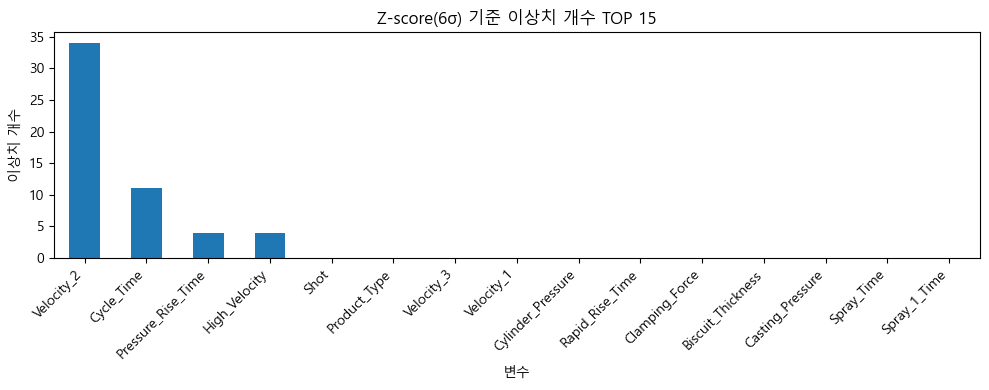

In [81]:
# 4) 그래프: TOP 15 막대그래프
top15 = z_count.head(15)

plt.figure(figsize=(10,4))
top15.plot(kind="bar")
plt.title("Z-score(6σ) 기준 이상치 개수 TOP 15")
plt.xlabel("변수")
plt.ylabel("이상치 개수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [85]:
# =========================
# Z-score(3σ) 이상치 "확인" (표 + 그래프 합본)
# =========================

z_th = 3

# 1) 컬럼별 평균/표준편차
mu = X.mean(numeric_only=True)
sigma = X.std(numeric_only=True, ddof=0)

# 표준편차 0인 컬럼 제외
sigma_zero = (sigma == 0)

# 2) Z-score & 이상치 마스크
z = (X - mu) / sigma
z_abs = z.abs()
z_outlier_mask = (z_abs > z_th)
z_outlier_mask.loc[:, sigma_zero] = False

# 3) 컬럼별 이상치 개수/비율
z_count = z_outlier_mask.sum().sort_values(ascending=False)
z_ratio = (z_count / len(X)).sort_values(ascending=False)

print("===== [Z-score 3σ] 이상치 TOP 15: 개수 =====")
print(z_count.head(15))
print()


rows_with_any = z_outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any, "/", len(X))
print("비율:", rows_with_any / len(X))
print()

===== [Z-score 3σ] 이상치 TOP 15: 개수 =====
Velocity_2            144
Biscuit_Thickness      36
Rapid_Rise_Time        22
Velocity_1             22
Velocity_3             18
Cycle_Time             15
High_Velocity          14
Factory_Temp            5
Pressure_Rise_Time      4
Cylinder_Pressure       4
Product_Type            0
Clamping_Force          0
Casting_Pressure        0
Shot                    0
Spray_Time              0
dtype: int64

이상치가 1개라도 있는 행 수: 226 / 7535
비율: 0.029993364299933642



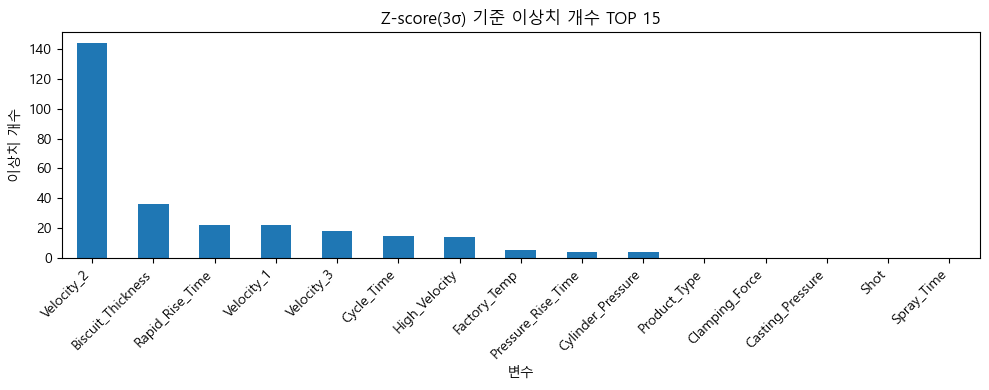

In [83]:
# 4) 그래프: TOP 15 막대그래프
top15 = z_count.head(15)

plt.figure(figsize=(10,4))
top15.plot(kind="bar")
plt.title("Z-score(3σ) 기준 이상치 개수 TOP 15")
plt.xlabel("변수")
plt.ylabel("이상치 개수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 식별자/그룹 구분 
생각해보니까 shot_key 이거 식별자라서 모델링 할땐 무조건 제거해야함.

In [25]:
# 1) shot_key 생성
process_df_clean = process_df.copy()
process_df_clean["shot_key"] = process_df_clean["id"].astype(str) + "_" + process_df_clean["Shot"].astype(str)

# 2) id, Shot 삭제
process_df_clean = process_df_clean.drop(columns=["id", "Shot"])

# 3) shot_key를 맨 앞으로 이동
cols = ["shot_key"] + [c for c in process_df_clean.columns if c != "shot_key"]
process_df_clean = process_df_clean[cols]

# 중복이 있으면 어떤 게 중복인지(있을 때만 의미 있음)
dup = process_df_clean["shot_key"][process_df_clean["shot_key"].duplicated(keep=False)]
print("중복 개수:", dup.shape[0])

중복 개수: 0


In [26]:
print(process_df["Product_Type"].value_counts())

Product_Type
1    4207
2    3328
Name: count, dtype: int64


# 전처리 결과 통합

In [27]:
process_df_clean.head()

,shot_key,Product_Type,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8


In [28]:
print("df shape:", df.shape)
df.head()

df shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

In [29]:
print("process_df_clean shape:", process_df_clean.shape)
process_df_clean.head()

process_df_clean shape: (7535, 16)


,shot_key,Product_Type,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8


In [30]:
print("sensor_df_clean shape:", sensor_df_clean.shape)
sensor_df_clean.head()

sensor_df_clean shape: (7535, 6)


,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity
0,695.0,6.3,26.0,2.71,32.9,58.4
1,696.4,6.3,26.1,2.69,32.9,58.2
2,696.4,6.3,26.1,2.69,32.9,58.2
3,696.4,6.3,26.1,2.69,32.9,58.2
4,697.9,6.4,26.1,2.69,32.9,57.8


In [31]:
print("group_df shape:", group_df.shape)
group_df.head()

group_df shape: (7535, 3)


,Surface_Defect,Structural_Defect,Contamination_Defect
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0


In [32]:
clean_df = pd.concat([process_df_clean, sensor_df_clean, group_df], axis=1)

print("clean_df shape:", clean_df.shape)
clean_df.head()

clean_df shape: (7535, 25)


,shot_key,Product_Type,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Surface_Defect,Structural_Defect,Contamination_Defect
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0,0,0
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,1,0
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0,0,0
